# Calculo de Tendencias por niveles
***
Created: 17/04/2026         &emsp;                           updated:12/05/2026


El script en esencia es el mismo que CalculaTendenciasNiveles.ipynb pero adaptado a necesidades especificas


In [72]:
# Packages for data manipulation
import numpy as np
import xarray as xr
import pandas as pd
import datetime as dt

# Package for tendency calculation
from scipy import stats

# Packages for visualization
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Package for progress bar
from tqdm import tqdm

# Package for file handling
import os

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

### Características previas

In [73]:
# Select grid resolution
grid_resolution = 1

# Press range
min_press = 4000
max_press = 4200

# Date Range
start_year = 1990
end_year = 2025

# Press steo
press_step = 100

# Code press for name
code_press =str(max_press - press_step) + 'k'

# Method for adjusting
robust = False

# Min data range
min_years = 10

# Select if grouop by years
group_by_years = False

### Apertura y recorte de los archivos

In [74]:
grid_res_str = str(grid_resolution).split('.')[-1]
grid = xr.open_dataset(f'./Data/grid/occupation_grid_{grid_res_str}.nc')
ds = xr.open_dataset('./Data/join/total_filt.nc')

In [75]:
grid

<xarray.Dataset> Size: 141MB
Dimensions:    (latitude: 181, longitude: 361, n_prof: 128)
Coordinates:
  * latitude   (latitude) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 88.0 89.0 90.0
  * longitude  (longitude) float64 3kB -180.0 -179.0 -178.0 ... 179.0 180.0
    n          (latitude, longitude) float64 523kB ...
    batimetry  (latitude, longitude) float64 523kB ...
    mask       (latitude, longitude) float64 523kB ...
    basin      (latitude, longitude) <U18 5MB ...
    surface    (latitude, longitude) float64 523kB ...
  * n_prof     (n_prof) int64 1kB 0 1 2 3 4 5 6 ... 121 122 123 124 125 126 127
    times      (latitude, longitude, n_prof) datetime64[ns] 67MB ...
Data variables:
    profiles   (latitude, longitude, n_prof) float64 67MB ...

In [76]:
ds

<xarray.Dataset> Size: 6GB
Dimensions:               (N_PROF: 21592, P: 6501)
Coordinates:
    time                  (N_PROF) datetime64[ns] 173kB ...
    section_id            (N_PROF) <U40 3MB ...
    file_name             (N_PROF) <U29 3MB ...
    latitude              (N_PROF) float64 173kB ...
    longitude             (N_PROF) float64 173kB ...
    pressure              (P) int64 52kB ...
Dimensions without coordinates: N_PROF, P
Data variables:
    ctd_temperature_filt  (N_PROF, P) float64 1GB ...
    ctd_salinity_filt     (N_PROF, P) float64 1GB ...
    ctd_oxygen_filt       (N_PROF, P) float64 1GB ...
    ctd_density_filt      (N_PROF, P) float64 1GB ...
    ctd_cp_filt           (N_PROF, P) float64 1GB ...

Recortamos ambos datasets por fechas y profundidades

In [77]:
# Cutting the dataset to have data from the wanted years
grid = grid.where((grid.times.dt.year >= start_year) & (grid.times.dt.year <= end_year), drop = True)

In [78]:
# Cutting the dataset to have data from exact pressure
if max_press is not None:
    ds = ds.where((ds.pressure <= max_press) & (ds.pressure >= min_press), drop=True)

else:
    ds = ds.where(ds.pressure >= min_press, drop=True)

### Función que devuelve tendencias para el nuevo dataset

In [79]:
def tendencias_nivel(ds, grid, press_step = 20, robust = False, min_years = 10, group_by_years = False):
    # Extract the wanted values
    latitude = grid.latitude.values
    longitude = grid.longitude.values
    pressure = ds.pressure.values
    n = grid.n.values
    profiles = grid.profiles.values
    time_array = ds.time.values

    # Create the array of pressures with the wanted step
    levels = np.arange(np.min(pressure), np.max(pressure), press_step)

    # Array which contain tendency for levels
    tendency_levels = np.full((len(latitude), len(longitude), len(levels)), np.nan)

    # Precalculating the valid indeces
    valid_idx = []
    for i in range(len(latitude)):
        for j in range(len(longitude)):
            # Check if there are profiles
            if not np.isnan(n[i, j]): 
                # Obtaining index of profiles with Nans
                profs = profiles[i, j, :] 
                profs = profs[~np.isnan(profs)].astype(int)

                # Precalculate the dates for this pixel
                dates = time_array[profs]
                valid_idx.append((i, j, profs, dates))

    for k in range(1, len(levels)):
        # Cut the matrix by levels
        ds_level = ds.isel(P = ((ds.pressure < levels[k]) & (ds.pressure >= levels[k-1])), drop=True)

        # Calculate the mean for all the profiles
        temp_mean_profs = ds_level.ctd_temperature_filt.mean(dim = 'P').values

        # Explore all the valid data
        for i, j, profs, prof_dates in valid_idx:
            # Extract the mean
            temp_mean = temp_mean_profs[profs]

            # Delete Nans
            valid = ~np.isnan(temp_mean)
            temp_mean = temp_mean[valid]
            valid_dates = prof_dates[valid]

            if group_by_years:
                years = valid_dates.astype('datetime64[Y]')
                unique_years = np.unique(years)


                # Check if there are more than 2 values
                if len(unique_years) <= 2:
                    continue 
                
                # Calculate the anual mean
                anual_temp = np.array([np.mean(temp_mean[years == y]) for y in unique_years])
                annual_dates = unique_years.astype('datetime64[ns]')


                # Check if the difference between dates is longer than 2.5 years
                sorted_dates = np.sort(valid_dates)
                if (sorted_dates[-1] - sorted_dates[0]) / np.timedelta64(365, 'D') >= min_years:
                    # Fit to a line curve
                    dates_pol = annual_dates.astype(np.int64)
                    if robust:
                        coefficients = stats.theilslopes(anual_temp, dates_pol) # Ajust by square minimun
                    else:
                        coefficients = np.polyfit(dates_pol, anual_temp, 1)

                    tendency = coefficients[0] / 1.e-9 * 24 * 3600 * 365 * 100 # Convert from ºC/ns to ºC/century

                    # Save the value
                    tendency_levels[i, j, k] = tendency

            else:
                # Check if there are more than 2 values
                if len(valid_dates) <= 2:
                    continue 
                
                # Check if the difference between dates is longer than 2.5 years
                sorted_dates = np.sort(valid_dates)
                if (sorted_dates[-1] - sorted_dates[0]) / np.timedelta64(365, 'D') >= 2.5:
                    # Fit to a line curve
                    dates_pol = valid_dates.astype('datetime64[ns]').astype(np.int64)
                    if robust:
                        coefficients = stats.theilslopes(temp_mean, dates_pol) # Ajust by square minimun
                    else:
                        coefficients = np.polyfit(dates_pol, temp_mean, 1)

                    tendency = coefficients[0] / 1.e-9 * 24 * 3600 * 365 * 100 # Convert from ºC/ns to ºC/century          
                    # Save the value
                    tendency_levels[i, j, k] = tendency


            

                
    return (latitude, longitude, levels, tendency_levels)

Aplicamos y guardamos en un netcdf

In [80]:
# Extract matrix of data
lat, lon, press_levels, tendency_levels = tendencias_nivel(ds = ds, grid = grid, press_step = press_step, robust = robust, min_years = min_years, group_by_years = group_by_years) 

In [81]:
# Creating the dataset
ds_tendency = xr.Dataset(
    # Variables
    data_vars = {'tendency' : (('latitude', 'longitude', 'pressure'), tendency_levels, {'units': 'ºC/century', 'description': 'Temperature tendency by levels between the asociated pressure value and the one before'})},

    # Coordinates
    coords = {
        'latitude' : (('latitude',), lat ),
        'longitude' : (('longitude',), lon),
        'pressure': (('pressure',), press_levels, {'units' : 'dbar'}),
        'mask' : (('latitude', 'longitude'), grid.mask.values)},

    # Metadates
    attrs = {'description' : f'Dataset of temperature tendencies by pressure levels between from pressures under {min_press} dbar and for years {start_year}-{end_year} with a spatial resolution of {grid_resolution} and a pressure resolution {press_step} dbar'}
)

# Save it in a NetCDF file
if robust:
    ds_tendency.to_netcdf(f'./Data/tendency_levels/tendency_levels_{start_year}_{end_year}_{str(grid_resolution).split('.')[-1]}_{code_press}_robust.nc')
else:
    ds_tendency.to_netcdf(f'./Data/tendency_levels/tendency_levels_{start_year}_{end_year}_{str(grid_resolution).split('.')[-1]}_{code_press}.nc')

In [82]:
ds_tendency

<xarray.Dataset> Size: 1MB
Dimensions:    (latitude: 142, longitude: 360, pressure: 2)
Coordinates:
  * latitude   (latitude) float64 1kB -78.0 -77.0 -76.0 -75.0 ... 61.0 62.0 63.0
  * longitude  (longitude) float64 3kB -180.0 -179.0 -178.0 ... 179.0 180.0
    mask       (latitude, longitude) float64 409kB 10.0 10.0 10.0 ... nan nan
  * pressure   (pressure) int64 16B 4000 4100
Data variables:
    tendency   (latitude, longitude, pressure) float64 818kB nan nan ... nan nan
Attributes:
    description:  Dataset of temperature tendencies by pressure levels betwee...

In [83]:
# Close all ds
ds.close()
grid.close()
ds_tendency.close()

### Contour

In [84]:
# Open dataset
if robust:
    ds_tendency = xr.open_dataset(f'./Data/tendency_levels/tendency_levels_{start_year}_{end_year}_{str(grid_resolution).split('.')[-1]}_{code_press}_robust.nc')
else:
    ds_tendency = xr.open_dataset(f'./Data/tendency_levels/tendency_levels_{start_year}_{end_year}_{str(grid_resolution).split('.')[-1]}_{code_press}.nc')

In [85]:
ds_tendency = ds_tendency.isel(pressure = 1)

In [86]:
# Importing the unique values of the mask
cuencas = np.unique(ds_tendency.mask.values)

basin_idx = [] # Number of the basin
basin_mean = [] # Tendency mean asociated
basin_std = [] # Tendency std asociated

# Iterate for every 'cuenca'
for cuenca in cuencas:
    if np.isnan(cuenca): # Skip is cuenca is Nan
        continue

    else:
        tendency = ds_tendency.tendency.where(ds_tendency.mask == cuenca).values
        tendency_mean = np.nanmean(tendency)
        tendency_std = np.nanstd(tendency)
        
        basin_idx.append(cuenca)
        basin_mean.append(tendency_mean)
        basin_std.append(tendency_std)

In [87]:
# Load the values of lat, lon and mask
latitudes = ds_tendency.latitude.values
longitudes = ds_tendency.longitude.values
mask = ds_tendency.mask.values

# Creating empty matrix
tendency_mean = np.full((len(latitudes), len(longitudes)), np.nan)
tendency_std = np.full((len(latitudes), len(longitudes)), np.nan)

# Iterate for each basin
for k, basin in enumerate(basin_idx):
    tendency_mean = np.where(mask == basin, basin_mean[k], tendency_mean)
    tendency_std = np.where(mask == basin, basin_std[k], tendency_std)

In [88]:
# Adding the variable to dataset
ds_tendency['tendency_mean'] = (('latitude', 'longitude'), tendency_mean)
ds_tendency['tendency_std'] = (('latitude', 'longitude'), tendency_std)

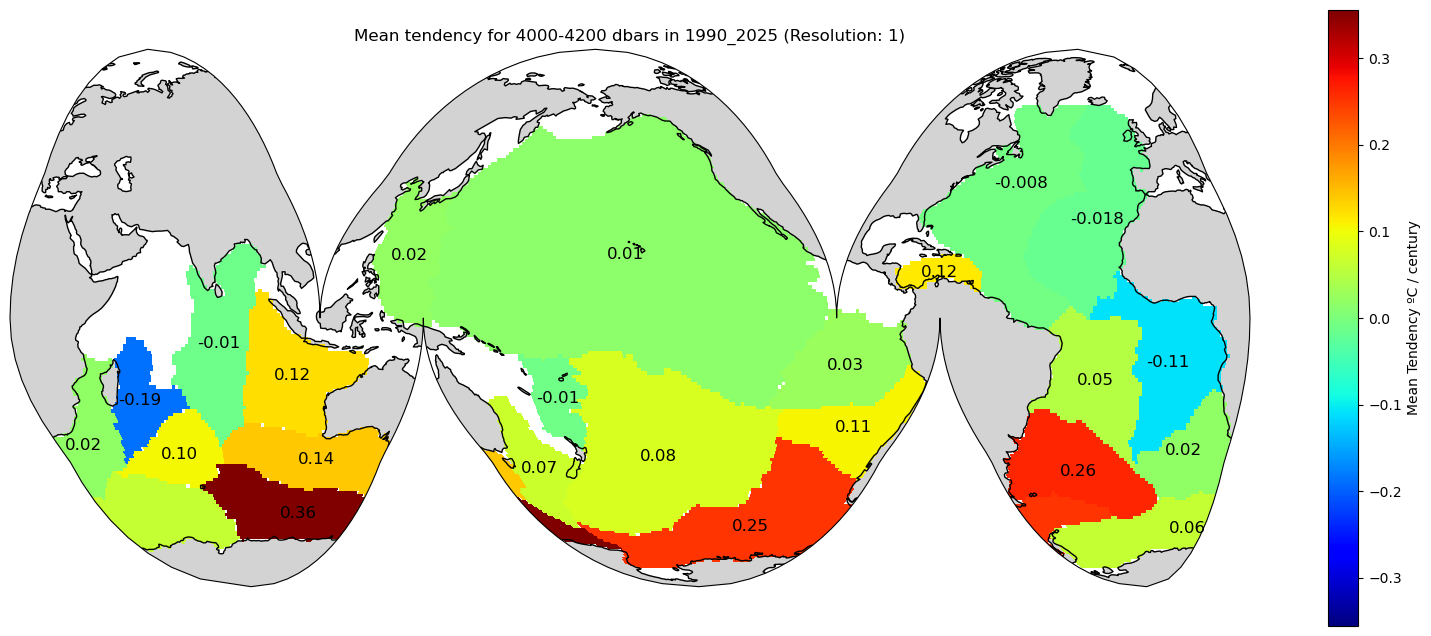

In [89]:
# Creating figure
fig, ax = plt.subplots(figsize=(20,10),
    subplot_kw={'projection': ccrs.InterruptedGoodeHomolosine(central_longitude=-160,emphasis='ocean')})

# Ploting mean
means = ds_tendency.tendency_mean.plot(ax = ax, cmap = "jet", transform = ccrs.PlateCarree(),  add_colorbar = False)

# Colorbar
fig.colorbar(mappable = means, shrink = 0.8, label = 'Mean Tendency ºC / century')


# Plotting features
ax.set_global()
ax.coastlines(resolution='110m')
ax.add_feature(cfeature.LAND, facecolor='lightgray')

# Title
ax.set_title(f'Mean tendency for {min_press}-{max_press} dbars in {start_year}_{end_year} (Resolution: {str(grid_resolution).split('.')[-1]})')

# Plotting text
for k, basin in enumerate(basin_idx):
    if not np.isnan(basin_mean[k]):
        latitude = ds_tendency.latitude.where(ds_tendency.mask == basin).values
        longitude = ds_tendency.longitude.where(ds_tendency.mask == basin).values

        # Normal mean for latitude
        mean_lat = np.nanmean(latitude)

        # Ciruclar mean for longitude
        lon_rad = np.radians(longitude)
        mean_lon = np.degrees(np.arctan2(np.nanmean(np.sin(lon_rad)), np.nanmean(np.cos(lon_rad))))

        if basin == 2:
            ax.text(mean_lon,mean_lat + 5, rf'{basin_mean[k]:.3f}', transform=ccrs.PlateCarree(),fontsize=12,ha='center',va='center',bbox=dict(facecolor='white', alpha=0,edgecolor='none'))
        elif basin == 1:
            ax.text(mean_lon,mean_lat - 5, rf'{basin_mean[k]:.3f}', transform=ccrs.PlateCarree(),fontsize=12,ha='center',va='center',bbox=dict(facecolor='white', alpha=0,edgecolor='none'))
        else: 
            ax.text(mean_lon,mean_lat, rf'{basin_mean[k]:.2f}', transform=ccrs.PlateCarree(),fontsize=12,ha='center',va='center',bbox=dict(facecolor='white', alpha=0,edgecolor='none'))
    else:
        continue

plt.savefig(f'./plots/MapasTendenciasArgo/Tendencias_{start_year}_{end_year}_{str(grid_resolution).split('.')[-1]}_{code_press}')

In [90]:
ds_tendency.close()
ds.close()
grid.close()
plt.close('all')